## Importación de dependencias

In [ ]:

import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

import pandas as pd

from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer


nltk.download('punkt_tab')

## Carga de datos

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("_all_movie_reviews.tsv", sep="\t")
df

,movie_name,review,rating
0,BLACK WIDOW,"The plot was good, but was disappointed with h...",3.5
1,BLACK WIDOW,The action is good but it's boring and uninter...,2.0
2,BLACK WIDOW,Only one bad CGI part but other than that it’s...,5.0
3,BLACK WIDOW,Not bad of a movie,3.5
4,BLACK WIDOW,It's a nice and watchable movie. There are bor...,3.5
...,...,...,...
500938,BLACK PANTHER,AMAZING!! And don't even need knowledge of the...,5.0
500939,BLACK PANTHER,A groundbreaking film and another solid entry ...,3.5
500940,BLACK PANTHER,A particular type of movie transports us to a ...,5.0
500941,BLACK PANTHER,Marvel Studios is on a roll lately. Their last...,4.5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500943 entries, 0 to 500942
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   movie_name  500943 non-null  object 
 1   review      500943 non-null  object 
 2   rating      500943 non-null  float64
dtypes: float64(1), object(2)
memory usage: 11.5+ MB


In [ ]:
df.groupby("movie_name")["rating"].describe()

,count,mean,std,min,25%,50%,75%,max
movie_name,,,,,,,,
ANT-MAN,7273.0,4.013200,0.856584,0.5,3.5,4.0,4.5,5.0
ANT-MAN AND THE WASP,3103.0,3.753626,1.093677,0.5,3.0,4.0,4.5,5.0
ANT-MAN AND THE WASP: QUANTUMANIA,12952.0,3.768916,1.331924,0.5,3.0,4.0,5.0,5.0
AVENGERS: AGE OF ULTRON,10368.0,3.917197,1.023839,0.5,3.5,4.0,5.0,5.0
AVENGERS: ENDGAME,20537.0,4.370648,1.145710,0.5,4.0,5.0,5.0,5.0
AVENGERS: INFINITY WAR,11952.0,4.345507,1.164076,0.5,4.0,5.0,5.0,5.0
BLACK PANTHER,15003.0,3.794008,1.478676,0.5,3.0,4.5,5.0,5.0
BLACK PANTHER: WAKANDA FOREVER,10830.0,4.161450,1.342080,0.5,4.0,5.0,5.0,5.0
BLACK WIDOW,8637.0,3.838717,1.307062,0.5,3.0,4.0,5.0,5.0


In [ ]:
df = df[df["movie_name"] == "THE INCREDIBLE HULK"]

In [ ]:
df

,movie_name,review,rating
32419,THE INCREDIBLE HULK,The Incredible Hulk is sadly a massive downgra...,2.5
32420,THE INCREDIBLE HULK,Why is iron man not in this movie? He’s green ...,0.5
32421,THE INCREDIBLE HULK,One of the more forgettable MCU films. Not bad...,3.0
32422,THE INCREDIBLE HULK,"Edward Norton stars for the first, and the las...",3.5
32423,THE INCREDIBLE HULK,Worst movie I’ve ever seen,0.5
...,...,...,...
66873,THE INCREDIBLE HULK,Marvel's done it again. Much better than the f...,4.5
66874,THE INCREDIBLE HULK,Everything I wanted in an Incredible Hulk movi...,4.0
66875,THE INCREDIBLE HULK,Really good! I loved it when he changed into t...,4.5
66876,THE INCREDIBLE HULK,Awesome movie. Loved it.,4.5


## Preprocessing

### Tokenización

In [ ]:
simplifier = PorterStemmer()

In [ ]:
def get_tokens(review, simplifier_func=None):

  tokens = word_tokenize(review)
  cleaned_tokens = []
  for token in tokens:
    if(len(token) > 500): continue
    if not token.isalpha(): continue
    token = token.lower()
    if simplifier_func: token = simplifier_func(token)
    cleaned_tokens.append(token)

  return " ".join(cleaned_tokens)

In [ ]:
df["Token String"] = df["review"].apply(lambda x: get_tokens(x, simplifier.stem))
df

,movie_name,review,rating,Token String
32419,THE INCREDIBLE HULK,The Incredible Hulk is sadly a massive downgra...,2.5,the incred hulk is sadli a massiv downgrad fro...
32420,THE INCREDIBLE HULK,Why is iron man not in this movie? He’s green ...,0.5,whi is iron man not in thi movi he s green so ...
32421,THE INCREDIBLE HULK,One of the more forgettable MCU films. Not bad...,3.0,one of the more forgett mcu film not bad just ...
32422,THE INCREDIBLE HULK,"Edward Norton stars for the first, and the las...",3.5,edward norton star for the first and the last ...
32423,THE INCREDIBLE HULK,Worst movie I’ve ever seen,0.5,worst movi i ve ever seen
...,...,...,...,...
66873,THE INCREDIBLE HULK,Marvel's done it again. Much better than the f...,4.5,marvel done it again much better than the firs...
66874,THE INCREDIBLE HULK,Everything I wanted in an Incredible Hulk movi...,4.0,everyth i want in an incred hulk movi with non...
66875,THE INCREDIBLE HULK,Really good! I loved it when he changed into t...,4.5,realli good i love it when he chang into the h...
66876,THE INCREDIBLE HULK,Awesome movie. Loved it.,4.5,awesom movi love it


### Vectorización

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True, max_features=4000, ngram_range=(1,2))
vectorizer.fit(df["Token String"])

TfidfVectorizer(max_features=4000, ngram_range=(1, 2), stop_words='english')

In [ ]:
X = pd.DataFrame(
    vectorizer.transform(df["Token String"]).toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df.index
)
X

,abil,abl,abomin,abomin hulk,abomin look,abomin wa,abov,abov averag,absolut,absolut love,...,year ago,year old,year thi,yell,yong,york,york citi,young,zak,zak penn
32419,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32420,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32421,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32422,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32423,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66874,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66875,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66876,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Reducción de dimensionalidad

In [ ]:
# Se hará una prueba de PCA a un vector reducido de 500 componentes principales

print(f"Dimensión de los vectores antes de reducción: {X.shape[1]}")

n_components = 500
pca = PCA(n_components=n_components, random_state=42)
pca.fit(X)
df_reduced = pd.DataFrame(pca.transform(X), columns=([f"c{i}" for i in range(n_components)]))

print(f"Dimensión de los vectores antes de reducción: {df_reduced.shape[1]}")
df_reduced

Dimensión de los vectores antes de reducción: 4000
Dimensión de los vectores antes de reducción: 500


,c0,c1,c2,c3,c4,c5,c6,c7,c8,c9,...,c490,c491,c492,c493,c494,c495,c496,c497,c498,c499
0,-0.087633,0.049265,0.037159,-0.039605,0.086209,0.015521,0.131951,-0.048592,-0.009995,0.030965,...,-0.010294,0.005123,-0.008138,0.021979,-0.043851,-0.019131,-0.012057,-0.007011,-0.001801,-0.019687
1,-0.039080,0.091947,0.133946,-0.103256,0.059150,0.160519,-0.181948,-0.029666,0.121429,0.014724,...,0.037619,0.028430,-0.021357,0.016650,-0.006246,0.018863,-0.037686,-0.009975,0.014933,-0.031567
2,-0.061528,-0.076403,-0.060132,0.053849,-0.005997,0.057052,0.017922,0.007202,-0.023059,0.046431,...,0.052114,0.026283,-0.016585,-0.044561,0.002241,0.026393,0.004539,-0.020692,-0.002483,0.029558
3,-0.087430,0.003913,-0.055340,0.145002,0.036626,0.076985,0.016063,0.131896,0.021742,0.074960,...,-0.033281,-0.019395,0.015667,-0.020844,0.019264,0.003819,-0.001178,-0.011971,-0.022055,-0.011465
4,-0.026376,-0.025578,0.029904,-0.017702,-0.123990,-0.007855,-0.067802,0.015791,-0.016262,-0.032216,...,0.005294,0.005180,-0.003422,-0.017914,-0.003153,-0.006759,0.006175,-0.009467,0.001472,0.001276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34454,0.065773,0.052606,0.004552,-0.058921,-0.103817,0.031304,-0.104701,0.041796,-0.082650,0.097953,...,0.000151,0.018232,0.002856,0.005660,-0.036889,-0.020565,-0.016326,-0.018097,-0.002749,-0.000226
34455,-0.044730,-0.009837,-0.043565,-0.105831,-0.088090,0.089647,0.054843,0.007883,-0.012706,-0.053559,...,-0.013154,-0.007874,0.017160,-0.002500,0.015618,0.006576,-0.002497,0.002183,-0.011764,-0.003111
34456,-0.063197,-0.057258,0.025812,0.066065,-0.022764,0.011862,0.062651,0.040971,-0.013681,0.011175,...,0.041509,-0.034385,0.002408,0.005578,-0.029346,0.004225,-0.039021,0.017519,0.066441,0.004489
34457,-0.047874,0.015069,0.016911,0.030699,-0.179448,0.032378,-0.171957,0.010790,0.021983,-0.119730,...,0.011921,0.003040,0.000408,-0.012152,-0.008644,0.003625,-0.007182,0.009497,-0.004023,-0.003303


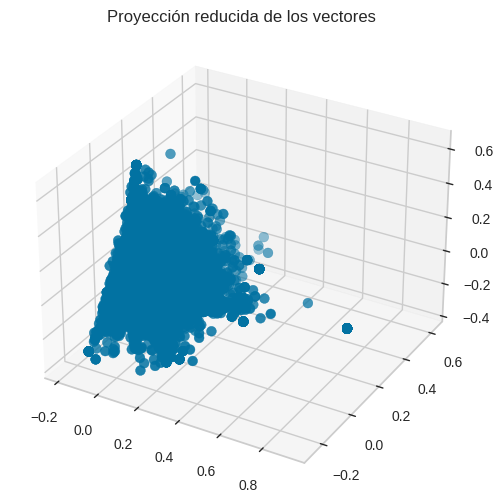

In [ ]:
# Grafiquemos los componentes en baja dimensionalidad con PCA

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(df_reduced.iloc[:,0], df_reduced.iloc[:,1], df_reduced.iloc[:,2], s=50)
ax.set_title("Proyección reducida de los vectores")
plt.show()

## Modelamiento

### Selección de número de clústers

El número óptimo de clusters es: 4


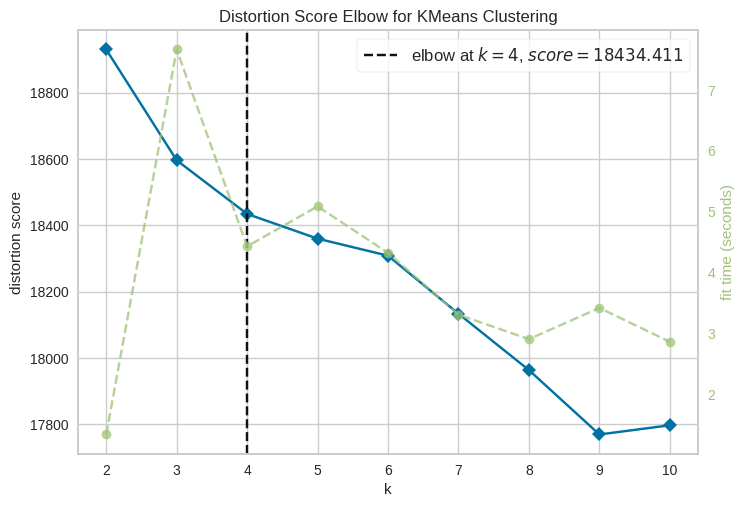

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
elbow = KElbowVisualizer(KMeans(random_state=42), k=10)
elbow.fit(df_reduced)
best_k = elbow.elbow_value_
print(f"El número óptimo de clusters es: {best_k}")
elbow.show()

### Clusterización

In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = kmeans.fit_predict(df_reduced)
df_reduced["Cluster"] = clusters
df_reduced.index = X.index
df_reduced

,c0,c1,c2,c3,c4,c5,c6,c7,c8,c9,...,c491,c492,c493,c494,c495,c496,c497,c498,c499,Cluster
32419,-0.087633,0.049265,0.037159,-0.039605,0.086209,0.015521,0.131951,-0.048592,-0.009995,0.030965,...,0.005123,-0.008138,0.021979,-0.043851,-0.019131,-0.012057,-0.007011,-0.001801,-0.019687,0
32420,-0.039080,0.091947,0.133946,-0.103256,0.059150,0.160519,-0.181948,-0.029666,0.121429,0.014724,...,0.028430,-0.021357,0.016650,-0.006246,0.018863,-0.037686,-0.009975,0.014933,-0.031567,1
32421,-0.061528,-0.076403,-0.060132,0.053849,-0.005997,0.057052,0.017922,0.007202,-0.023059,0.046431,...,0.026283,-0.016585,-0.044561,0.002241,0.026393,0.004539,-0.020692,-0.002483,0.029558,0
32422,-0.087430,0.003913,-0.055340,0.145002,0.036626,0.076985,0.016063,0.131896,0.021742,0.074960,...,-0.019395,0.015667,-0.020844,0.019264,0.003819,-0.001178,-0.011971,-0.022055,-0.011465,3
32423,-0.026376,-0.025578,0.029904,-0.017702,-0.123990,-0.007855,-0.067802,0.015791,-0.016262,-0.032216,...,0.005180,-0.003422,-0.017914,-0.003153,-0.006759,0.006175,-0.009467,0.001472,0.001276,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66873,0.065773,0.052606,0.004552,-0.058921,-0.103817,0.031304,-0.104701,0.041796,-0.082650,0.097953,...,0.018232,0.002856,0.005660,-0.036889,-0.020565,-0.016326,-0.018097,-0.002749,-0.000226,0
66874,-0.044730,-0.009837,-0.043565,-0.105831,-0.088090,0.089647,0.054843,0.007883,-0.012706,-0.053559,...,-0.007874,0.017160,-0.002500,0.015618,0.006576,-0.002497,0.002183,-0.011764,-0.003111,0
66875,-0.063197,-0.057258,0.025812,0.066065,-0.022764,0.011862,0.062651,0.040971,-0.013681,0.011175,...,-0.034385,0.002408,0.005578,-0.029346,0.004225,-0.039021,0.017519,0.066441,0.004489,3
66876,-0.047874,0.015069,0.016911,0.030699,-0.179448,0.032378,-0.171957,0.010790,0.021983,-0.119730,...,0.003040,0.000408,-0.012152,-0.008644,0.003625,-0.007182,0.009497,-0.004023,-0.003303,0


## Análisis de resultados

In [ ]:
# Escogiendo una paleta de colores uniforme para el resto del análisis
viridis = plt.colormaps['viridis']
palette = [mcolors.to_hex(viridis(i / (best_k-1))) for i in range(best_k)]
print("Paleta de colores:", palette)

Paleta de colores: ['#440154', '#31688e', '#35b779', '#fde725']


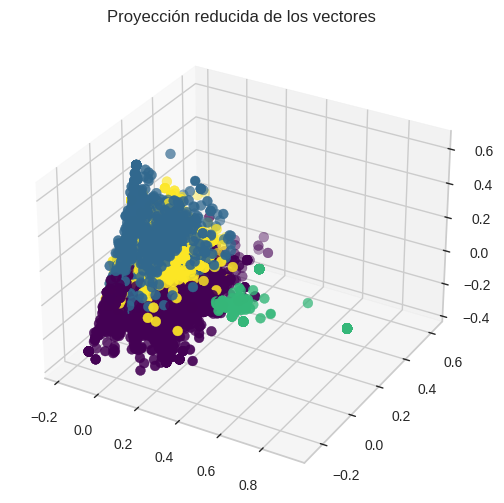

In [ ]:
# Grafiquemos los componentes con los clusters
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(df_reduced.iloc[:,0], df_reduced.iloc[:,1], df_reduced.iloc[:,2], s=50, c=df_reduced["Cluster"], cmap=viridis)
ax.set_title("Proyección reducida de los vectores")
plt.show()

In [ ]:
# Veamos las métricas de calidad internas
print(f"Davies-Bouldin Score: {davies_bouldin_score(df_reduced, clusters)}")
print(f"Calinski-Harabasz Score: {calinski_harabasz_score(df_reduced, clusters)}")

Davies-Bouldin Score: 1.1688486648426126
Calinski-Harabasz Score: 25991.176673824968


Cluster
0    0.728866
3    0.151949
1    0.101048
2    0.018137
Name: proportion, dtype: float64


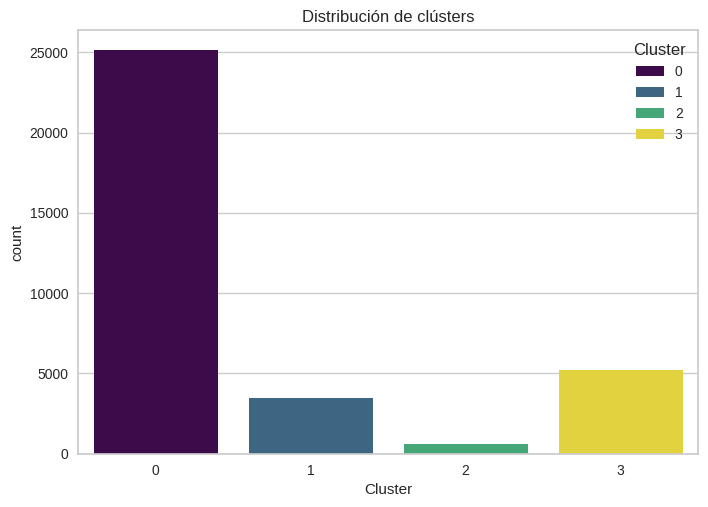

In [ ]:
# Veamos la proporción de clústers
print(df_reduced["Cluster"].value_counts(normalize=True))
sns.countplot(x=df_reduced["Cluster"], hue=df_reduced["Cluster"], palette=palette)
plt.title("Distribución de clústers")
plt.show()

In [ ]:
df["Cluster"] = df_reduced["Cluster"]
df

,movie_name,review,rating,Token String,Cluster
32419,THE INCREDIBLE HULK,The Incredible Hulk is sadly a massive downgra...,2.5,the incred hulk is sadli a massiv downgrad fro...,0
32420,THE INCREDIBLE HULK,Why is iron man not in this movie? He’s green ...,0.5,whi is iron man not in thi movi he s green so ...,1
32421,THE INCREDIBLE HULK,One of the more forgettable MCU films. Not bad...,3.0,one of the more forgett mcu film not bad just ...,0
32422,THE INCREDIBLE HULK,"Edward Norton stars for the first, and the las...",3.5,edward norton star for the first and the last ...,3
32423,THE INCREDIBLE HULK,Worst movie I’ve ever seen,0.5,worst movi i ve ever seen,0
...,...,...,...,...,...
66873,THE INCREDIBLE HULK,Marvel's done it again. Much better than the f...,4.5,marvel done it again much better than the firs...,0
66874,THE INCREDIBLE HULK,Everything I wanted in an Incredible Hulk movi...,4.0,everyth i want in an incred hulk movi with non...,0
66875,THE INCREDIBLE HULK,Really good! I loved it when he changed into t...,4.5,realli good i love it when he chang into the h...,3
66876,THE INCREDIBLE HULK,Awesome movie. Loved it.,4.5,awesom movi love it,0


Podemos ver a continuación, que los clústers no tienen una correlación directa con el rating, por lo que es claro que la clusterización agrupó por temas no por sentimiento.

In [ ]:
df.groupby("Cluster")["rating"].describe()

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,25116.0,3.684982,0.937720,0.5,3.0,4.0,4.5,5.0
1,3482.0,3.769529,0.741280,0.5,3.5,4.0,4.0,5.0
2,625.0,3.883200,0.715526,0.5,3.5,4.0,4.5,5.0
3,5236.0,3.704068,0.760059,0.5,3.5,4.0,4.0,5.0


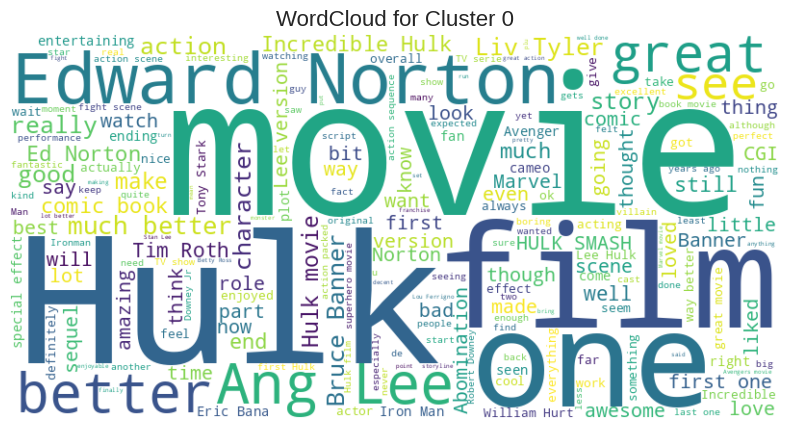

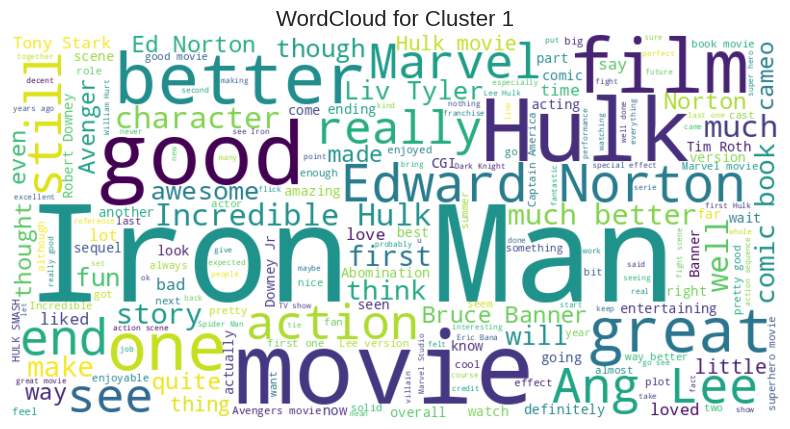

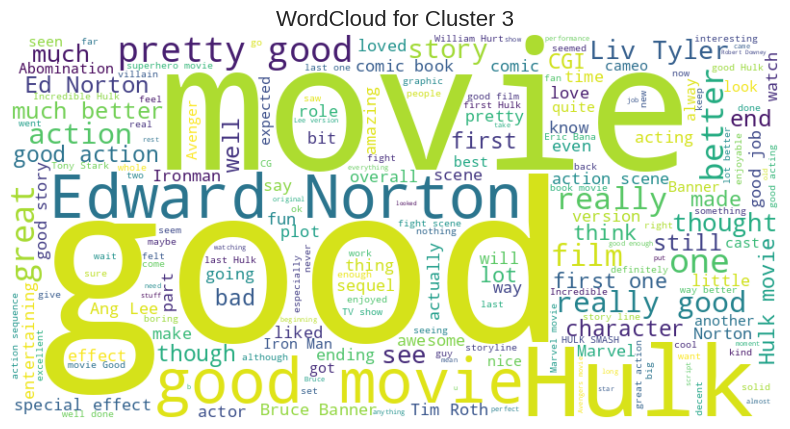

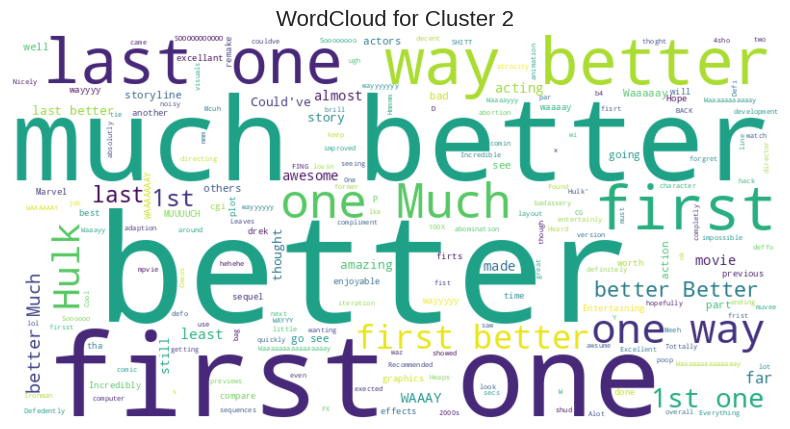

In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Example DataFrame
# df = pd.DataFrame({
#     'text': ["I love data science", "Machine learning is fun", "Data analysis is key"],
#     'cluster': [0, 1, 0]
# })

# Get unique clusters
clusters = df['Cluster'].unique()

# Generate a word cloud per cluster
for cluster in clusters:
    # Combine all text for this cluster
    text = " ".join(df[df['Cluster'] == cluster]['review'].astype(str))

    # Generate word cloud
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)

    # Plot it
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud for Cluster {cluster}", fontsize=16)
    plt.show()


Como vemos en el wordcloud se encontraron diferentes grupos de reviewers:
1. La población general que da una opinión holística de la película.
2. Los que la comparan con Iron Man.
3. Los fans que en general hablan de los aspectos positivos.
4. Los que la comparan con la primera película.

Más abajo, podemos ver esto envidenciado al explorar los comentarios por cluster.

In [ ]:
df[df["Cluster"] == 0]["review"]

,review
32419,The Incredible Hulk is sadly a massive downgra...
32421,One of the more forgettable MCU films. Not bad...
32423,Worst movie I’ve ever seen
32424,This movie is better then the 2003 hulk by sto...
32425,the second installment to the MCU while much d...
...,...
66871,A very competent comic book movie in its own r...
66872,"I mostly like Marvel-movies, but this has some..."
66873,Marvel's done it again. Much better than the f...
66874,Everything I wanted in an Incredible Hulk movi...


In [ ]:
df[df["Cluster"] == 1]["review"]

,review
32420,Why is iron man not in this movie? He’s green ...
32436,"This movie is way worse than Iron man, but Edw..."
32496,Good movie for the 2nd installment for the mcu...
32521,After Iron Man I thought this is going to be m...
32522,Idk how tf the cgi was better in Iron Man than...
...,...
66846,"I'll say this first, as I'm sure this is all y..."
66864,"Pretty much just as good as Iron Man, but with..."
66867,"Freaking wow. Amazingly well done, I suspect E..."
66868,The original theme song from the show and Lou ...


In [ ]:
df[df["Cluster"] == 2]["review"]

,review
33318,better than the previous but still could have ...
33474,Better than the 2003 Hulk movie. WAY better.
33475,Better then the 2003 Hulk
33685,100% better than the 1st one!
33828,so much better than the first
...,...
66286,So much better than the other one.
66303,"June 21, 2008 better than the first"
66352,so much better than the first!
66526,better than the first one


In [ ]:
df[df["Cluster"] == 3]["review"]

,review
32422,"Edward Norton stars for the first, and the las..."
32427,"It was a good movie, Hulk was used very well a..."
32443,It’s a really good movie.
32449,"The first act was eh, and moreless confusing, ..."
32463,"Solid, middle of the road action movie. I defi..."
...,...
66818,"Once again, this summer throws out another awe..."
66827,"Great action, decent movie. It felt like it wa..."
66832,It was good. Not amazing but I liked that it w...
66875,Really good! I loved it when he changed into t...
